# Logistic Regression Training and Hyperparameter Tuning

This notebook demonstrates how to train a logistic regression model using
mini-batch SGD, perform hyperparameter tuning, and analyze results. We use Comet
ML for experiment tracking.

---

## Initialization and Data Prep

A series of preparations must first be underway before model training. Importing certain libraries for visualizations, metrics, and the like.

### Imports and Initializations

There are a variety of libraries to work with. `sklearn` is deemed the most significant due to its vast range of machine learning libraries. There are also visualization imports such as `seaborn` and `matplotlib`. `comet_ml` was also utilized for tracking the model's metrics during training.

In [ ]:
from scipy.stats import loguniform
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from dotenv import load_dotenv
import comet_ml
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import sys
import os

# Set up project paths
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.append(project_root)

from src.logreg import MinibatchSGDWrapper

# Initialize Comet ML
# Used for metrics and training tracking
load_dotenv()
api_key = os.getenv("COMET_API_KEY")
comet_ml.login(api_key=api_key)

exp = comet_ml.start(project_name="logreg-hyperparam-tuning")
exp.set_name("LogReg Hyperparam Tuning")
exp.add_tag("logreg")

df = pd.read_csv("../data/data_processed.csv")

df.info()
df.head()

### Target separation

Explicitly separate features and target variable for clarity. There is also
no further need to split the data due to the use of `standardscaler`.

In [ ]:
# target separation
X = df.drop(columns=["won"])  # features
y = df["won"]  # target variable

### Data split

Split the data into training and testing sets.

The data split will be **85%/15%** for this section due to `RandomizedSearchCV`
automated validation split. The mentioned library function is capable of
automatically splitting the fed data into 15%. Therefore, further splitting the
data here will lead to 15% loss in the data due to excess splits.

In [ ]:
# Split data into training and validation
# 85% / 15% split
# RandomizedSearchCV will automatically do a 15% split for validation
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=42
)

# Check sizes of splits
print(f"Training data: {X_train.shape}")
print(f"Training labels: {y_train.shape}")
print(f"Testing data: {X_test.shape}")
print(f"Testing labels: {y_test.shape}")

## Model Training

The logistic regression model will be trained via 70% of the dataset.

Training the logistic regression model composed of 2 phases:

- **Phase 1**: Identify optimal epoch through an initial training using a fixed
  learning rate of 0.001 and at a maximum of 150 epochs with a batch size of 64.
  Plotting the loss curve helps identify where the loss flattens.
- **Phase 2**: Tune hyperparameters through 50 iterations using mini-batch
  stochastic gradient descent. Parameters will be tuned using
  `RandomizedSearchCV` from fixed batch sizes of 32, 64, and 128 and a
  learning rate range of 0.0001 to 0.1.

Finding the optimal epoch first allows for resource conservation. In addition to
that, the pipeline uses mini-batch SGD for better computational advantage.

### Determine Optimal Epoch

Trains a pilot model with fixed parameters:

- `learning_rate` (eta0) = 0.001
- `epochs` = 150
- `batch_size` = 64

Training data was also scaled appropriately.

In [ ]:
# Run pilot model to test optimal epochs
pilot_model = MinibatchSGDWrapper(eta0=0.001, epochs=150, batch_size=32)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# Run the training
print("Training pilot model...")
pilot_model.fit(X_train_scaled, y_train)
print("Done!")

Loss is plotted against epochs, easily visualizing where the loss
curve flattens.

In [ ]:
# Check learning curve
plt.figure(figsize=(10, 6))
plt.plot(
    range(1, len(pilot_model.loss_history_) + 1),
    pilot_model.loss_history_,
    color="firebrick",
    linewidth=2,
)

plt.title("Learning Curve: Loss vs. Epochs", fontsize=14)
plt.xlabel("Epochs", fontsize=12)
plt.ylabel("Log Loss (Training)", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.7)
plt.show()

print(f"Final Loss at Epoch 150: {pilot_model.loss_history_[-1]:.4f}")

Evidently, the loss flattens around 40+ epochs. Thus, the safe set
of epochs determined will be 50.

## Hyperparameter Tuning

After determining the ideal epoch (50), it will then be set as a fixed hyperparameter for the hyperparameter tuning phase. This avoids overfitting and applies the least validation loss. First, instantiate a `Pipeline()` object that consists of standardization, followed by the model. Then, set the parameter ranges, where `logreg_batch_size` is randomly selected from the ranges of 32, 64, and 128, and then the learning rate (`logreg_eta0`) from 0.0001 to 0.1. The selected iterations will also be 50, allowing for a broad range of possible combinations.

In [ ]:
# Perform hyperparameter tuning
# Instantiate pipeline with SGDWrapper
pipeline = Pipeline([("scaler", StandardScaler()),
                    ("logreg", MinibatchSGDWrapper())])

# Define hyperparameter ranges
param_dist = {
    "logreg__eta0": loguniform(1e-4, 1e-1),
    #
    "logreg__batch_size": [32, 64, 128],
    # Set best epochs
    "logreg__epochs": [50],
}

# RandomizedSearchCV is more robust than manual iterations as the former runs jobs in parallel
random_search = RandomizedSearchCV(
    pipeline,
    param_distributions=param_dist,
    n_iter=50,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    random_state=42,
    verbose=1,
)

After instantiations, perform hyperparameter tuning.

In [ ]:
# Tune hyperparameter via random_search
random_search.fit(X_train, y_train)

The `Pipeline()` shows the parameters of each step in its process.

### Best Hyperparameters

After hyperparameter tuning, log the parameters of the model with the lowest loss.

In [17]:
# Log best model
best_model = random_search.best_estimator_

print(f"Best Params: {random_search.best_params_}")
print(f"Best CV Accuracy: {random_search.best_score_:.4f}")

Best Params: {'logreg__batch_size': 64, 'logreg__epochs': 50, 'logreg__eta0': 0.0018856783874794994}
Best CV Accuracy: 0.8995


From the results, a learning rate (`logreg_eta0`) of 0.001886 and a `logreg_batch_size` of 64 yielded a cross-validation accuracy of 0.8995, which `RandomizedSearchCV` dictated to be the best hyperparameters for the model and its data.

### Results

Load results into a dataframe for matplot and seaborn visualizations.

In [ ]:
# Load results into a df
results_df = pd.DataFrame(random_search.cv_results_)
results_df["param_logreg__eta0"] = pd.to_numeric(
    results_df["param_logreg__eta0"])
results_df["param_logreg__epochs"] = pd.to_numeric(
    results_df["param_logreg__epochs"])
results_df["param_logreg__batch_size"] = pd.to_numeric(
    results_df["param_logreg__batch_size"]
)

#### Impact of adjusting the learning rate on accruacy

Shown is the impact of learning rate on the model's `mean_test_score` across 50 iterations.

In [ ]:
# Impact of adjusting the learning rate on accruacy
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=results_df,
    x="param_logreg__eta0",
    y="mean_test_score",
    hue="param_logreg__batch_size",
    palette="viridis",
    size=200,
    legend=False,
)
sns.regplot(
    data=results_df,
    x="param_logreg__eta0",
    y="mean_test_score",
    scatter=False,
    order=1,  # Uses polynomial regression instead of LOWESS
    color="red",
    line_kws={"linestyle": "--", "linewidth": 2},
)

plt.xscale("log")
plt.title("Impact of Learning Rate on Accuracy")
plt.xlabel("Initial Learning Rate (eta0)")
plt.ylabel("Mean Test Accuracy")
plt.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

The peak accuracy can be achieved using a learning rate of **0.001 to 0.005**. The model's accuracy falls off in a sharp curve from 0.01 and more, while a slower decreasing curve from 0.001 and less.

#### Impact of adjusting the batch size on accruacy

Shown is the impact of batch size on the model's `mean_test_score` across 50 iterations.

In [ ]:
# Impact of batch size on accuracy
plt.figure(figsize=(8, 6))

sns.lineplot(
    data=results_df,
    x="param_logreg__batch_size",
    y="mean_test_score",
    marker="o",
    color="royalblue",
    errorbar="sd",  # Shows the standard deviation as a shaded band
)

# Forces the x-axis to only show your exact batch sizes
plt.xticks([32, 64, 128])
plt.title("Impact of Batch Size on Accuracy")
plt.xlabel("Batch Size")
plt.ylabel("Mean Test Accuracy")
plt.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

The `mean_test_score` of the model appears higher at batch sizes of 64. Thus, this will be concluded as the best batch size for the model.

## Model Testing and Results

After the model is trained on 70% of the data and validated on 15%, it will be tested on the remaining 15%.

### Classification Report on test set

A classification report is automatically generated based on the model's performance on its predictions on `X_test`.

In [21]:
# Test best model on test data
y_pred_test = best_model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_pred_test)

print(f"Test Accuracy: {test_accuracy:.4f}")
print("\nClassification Report (Test Set):\n")
print(classification_report(y_test, y_pred_test))

Test Accuracy: 0.8950

Classification Report (Test Set):

              precision    recall  f1-score   support

           0       0.90      0.87      0.89      5353
           1       0.89      0.92      0.90      6151

    accuracy                           0.89     11504
   macro avg       0.90      0.89      0.89     11504
weighted avg       0.90      0.89      0.89     11504



The model has an **89%** accuracy, hence it predicted 9/10 times. The `f1-score` is also placed 89% and 90% respectively for loss and wins, showcasing an exceptionally balanced model. There is also no evident case of overfitting in the results.

### Confusion Matrix on test set

The confusion matrix helps us visualize the quantifiable loss.

In [ ]:
# Test set confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred_test)
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix (Test Data)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

Out of the 11,000+ instances, **only 1208** were falsely predicted.

### Probabilities for predictions

This section shows the probability confidence of the model. The sigmoid function
produces a probability from 0-1, and this value determines the final
classification. By default, any result with a _P(Win)_ >= 0.5
is labeled a match won (1), while anything below is a match lost (0).

In [23]:
# Predictions on test set
# SGDClassifier supports the `predict_proba` method for estimating probabilities
y_proba = best_model.predict_proba(X_test)

# Display head predictions with probabilities
print("Predicted Probabilities (First 5 Test Examples):\n")
for i, (prob_0, prob_1) in enumerate(y_proba[:5]):
    print(f"Example {i+1}: P(Loss)={prob_0:.4f}, P(Win)={prob_1:.4f}")

Predicted Probabilities (First 5 Test Examples):

Example 1: P(Loss)=0.9839, P(Win)=0.0161
Example 2: P(Loss)=0.0297, P(Win)=0.9703
Example 3: P(Loss)=0.0093, P(Win)=0.9907
Example 4: P(Loss)=0.4710, P(Win)=0.5290
Example 5: P(Loss)=0.4170, P(Win)=0.5830


The probabilities produced by the model can be differentiated into two:

- High confidence, where probability of winning or losing is 95%+. This
  means that the model interpreted the match statistics as one-sided, where
  a player completely swept their opponent.
- Medium confidence, with probabilities ranging from 40-60%. This means
  that the model interpreted the match statistics as a close fight, where
  two players are going head-to-head with attacks.

### Feature weights

The weights of the features help us understand what factors in Tetrio
contribute to winning.

In [ ]:
# Feature impact
inner_model = best_model.named_steps["logreg"].model
feature_weights = inner_model.coef_[0]

# Map weights to feature names
feature_importances = pd.Series(data=feature_weights, index=X.columns).sort_values(
    ascending=False
)

print("Top 5 Positive Features (Increase P(Win)):\n")
print(feature_importances.head())

print("-" * 30)

print("Top 5 Negative Features (Increase P(Loss)):\n")
print(feature_importances.tail().sort_values(ascending=True))

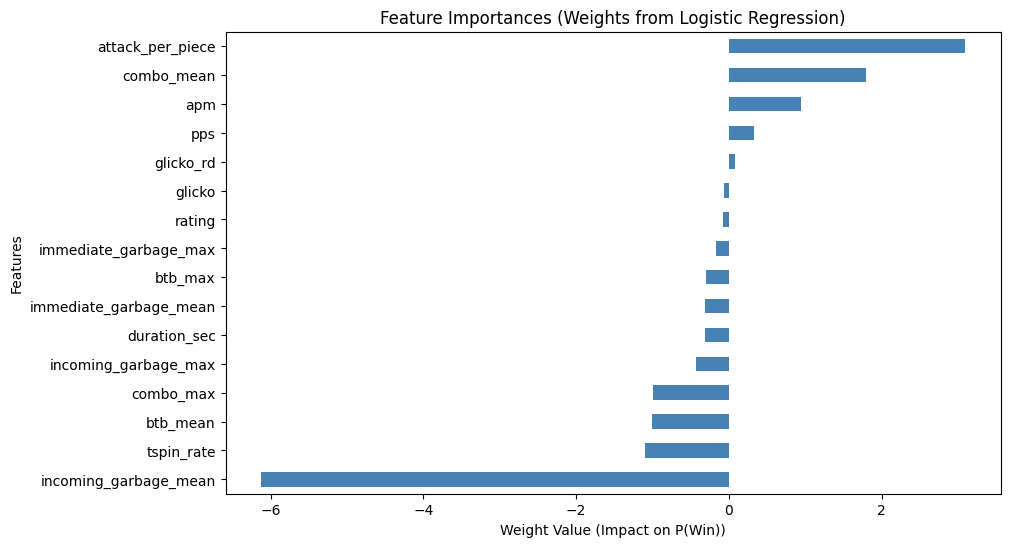

In [25]:
# Feature impact visualization
plt.figure(figsize=(10, 6))
feature_importances.sort_values().plot(kind="barh", color="steelblue")
plt.title("Feature Importances (Weights from Logistic Regression)")
plt.xlabel("Weight Value (Impact on P(Win))")
plt.ylabel("Features")
plt.show()

From the determined feature weights, we can clearly visualize what
contributes to winning in a Tetrio match:

- `attack_per_piece`: **The abundance of attacks in a match is the
  most positive contributor** to winning a Tetrio match. `pps` or
  pieces per second dictates how often a player places a piece in
  a match. With its feature importance weighed at only 0.33, it goes
  to show that **efficiency (better attacks) wins more matches** than
  quickly placing pieces.
- `incoming_garbage`: The amount of garbage received in a match
  is the **most dominant contributor to losing**. Receiving a large
  amount of garbage tends to lead to losses. This suggests that the
  model is very sensitive to a player's inability to clear garbage.
  If a player fails to clear garbage despite a high `attack_per_piece`,
  then they are likely to lose.
- `combo_mean` vs. `combo_max`: `combo_mean` is the second-highest
  positive contributor to winning. Thus, **maintaining a higher average combo
  leads to better chances of winning** in a Tetrio match. On the other hand,
  `combo_max` is a negative contributor. Decisions such as going for a quad
  (4-wide clear) or t-spin triple at crucial moments are riskier moves that
  can leave a player vulnerable to counter-spikes (massive `incoming_garbage`).
- `tspin_rate` & `btb_mean`: High attack moves such as t-spins and back-to-back
  moves turn out to be negative contributors. This does not mean that such moves
  are considered negative, but rather **prioritizing flashy setups can be very risky
  for a player**. It may remove their defensive timing and leave them open to `incoming_garbage`.